# Interpreting the ESO spectrum object-type output

This notebook reads the SQLite database produced by `eso-object-types run`. It explains how ESO spectra, catalog objects, object types, and positional links fit together.

Important scientific interpretation:

- A link means that a catalog object lies inside the cone used for an ESO spectrum.
- It does **not** mean that the object was detected in the spectrum or was the intended target.
- The prototype radius is `max(s_fov / 2, 1 arcsec)`. For production, the meaning of `s_fov` should be validated by instrument and replaced by `s_region` where appropriate.
- Only the primary SIMBAD type is stored.

In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current directory")

REPO_ROOT = find_repository_root(Path.cwd().resolve())
DB_PATH = REPO_ROOT / "output" / "eso_object_types.sqlite"
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}. Run `eso-object-types run` first."
    )

connection = sqlite3.connect(DB_PATH)
print(f"Database: {DB_PATH}")

Database: /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/ESOArchive_objects/output/eso_object_types.sqlite


## 1. Select a pipeline run

The database can contain several runs. By default, the notebook selects the latest one. Change `RUN_ID` below if you want to inspect an older run.

In [2]:
runs = pd.read_sql_query(
    """
    SELECT run_id, started_at, finished_at, status, config_json, summary_json
    FROM pipeline_runs
    ORDER BY started_at DESC
    """,
    connection,
)
if runs.empty:
    raise RuntimeError("The database contains no pipeline runs")

display(runs[["run_id", "started_at", "finished_at", "status"]])
RUN_ID = runs.loc[0, "run_id"]
run_config = json.loads(runs.loc[0, "config_json"])
run_summary = json.loads(runs.loc[0, "summary_json"] or "{}")
print(f"Selected run: {RUN_ID}")
display(pd.Series(run_config, name="value").rename_axis("setting").to_frame())

,run_id,started_at,finished_at,status
0,20261001T123609Z-22f018,2026-10-01T12:36:09.924130+00:00,2026-10-01T12:36:16.376027+00:00,completed
1,20261001T113845Z-3405c9,2026-10-01T11:38:45.709967+00:00,2026-10-01T11:38:47.243697+00:00,completed


Selected run: 20261001T123609Z-22f018


,value
setting,
eso_endpoint,https://archive.eso.org/tap_obs
limit,5000
min_radius_arcsec,1.0
output_dir,output
retries,5
simbad_alias_batch_size,10000
simbad_batch_size,50000
simbad_endpoint,https://simbad.cds.unistra.fr/simbad/sim-tap


## 2. Understand the relational model

The central relationship is:

`pipeline_runs -> run_observations -> observations -> observation_objects -> catalog_objects -> object_types`

- `observations` contains one row for each ESO data product, keyed by `eso_dp_id`.
- `run_observations` says which ESO rows belong to this run.
- `catalog_objects` stores each SIMBAD object once, keyed by `(catalog, catalog_object_id)`.
- `observation_objects` is the many-to-many link table. One spectrum can contain several objects, and one object can fall within several spectra.
- `object_types` avoids repeating type labels and descriptions for every object.
- `service_calls` records batching, attempts, timing, completion, and failures.

In [3]:
service_calls = pd.read_sql_query(
    """
    SELECT service, batch_number, input_count, attempt_count, result_count,
           status, ROUND(elapsed_seconds, 3) AS elapsed_seconds,
           error_type, error_message
    FROM service_calls
    WHERE run_id = ?
    ORDER BY service, batch_number
    """,
    connection,
    params=(RUN_ID,),
)
display(service_calls)

,service,batch_number,input_count,attempt_count,result_count,status,elapsed_seconds,error_type,error_message
0,eso,1,5000,1,5000,completed,1.585,None,None
1,simbad,1,1593,1,6489,completed,2.800,None,None
2,simbad_alias,1,1289,1,10882,completed,1.738,None,None


## 3. Inspect the ESO spectrum sample

`search_radius_arcsec` is the actual matching radius. `s_fov_arcsec` is the full characteristic field of view reported by ESO. The order-10 HEALPix value is a spatial partition key for future scaling, not a match criterion.

In [4]:
observations = pd.read_sql_query(
    """
    SELECT o.eso_dp_id, o.target_name, o.instrument_name,
           o.ra_deg, o.dec_deg,
           ROUND(o.s_fov_deg * 3600.0, 4) AS s_fov_arcsec,
           ROUND(o.search_radius_deg * 3600.0, 4) AS search_radius_arcsec,
           o.healpix_order10, o.s_region
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    WHERE ro.run_id = ?
    ORDER BY o.eso_dp_id
    """,
    connection,
    params=(RUN_ID,),
)
print(f"ESO spectra in run: {len(observations)}")
display(observations.head(10))

ESO spectra in run: 5000


,eso_dp_id,target_name,instrument_name,ra_deg,dec_deg,s_fov_arcsec,search_radius_arcsec,healpix_order10,s_region
0,ADP.2014-01-20T10:01:42.390,OGLE-2013-SN-011,EFOSC,71.795500,-64.043472,1.0,1.0,8485379,POSITION J2000 71.7955 -64.043472
1,ADP.2014-01-20T10:01:42.403,LSQ13sj,EFOSC,199.574000,-2.861916,1.0,1.0,6614984,POSITION J2000 199.574 -2.861916
2,ADP.2014-01-20T10:01:42.423,LSQ12dyw,EFOSC,352.353666,-7.389083,1.0,1.0,4438580,POSITION J2000 352.353666 -7.389083
3,ADP.2014-01-20T10:01:42.430,LSQ12cda,EFOSC,207.509708,9.629805,1.5,1.0,6776171,POSITION J2000 207.509708 9.629805
4,ADP.2014-01-20T10:01:42.443,LSQ12ezn,EFOSC,54.439875,-37.265750,1.0,1.0,8839502,POSITION J2000 54.439875 -37.26575
5,ADP.2014-01-20T10:01:42.450,OGLE-2012-SN-006,EFOSC,53.394958,-74.394472,1.0,1.0,8442060,POSITION J2000 53.394958 -74.394472
6,ADP.2014-01-20T10:01:42.463,SN2012ht,EFOSC,163.344790,16.776360,1.0,1.0,7243402,POSITION J2000 163.34479 16.77636
7,ADP.2014-01-20T10:01:42.470,SN2012ca,EFOSC,280.280210,-41.794000,1.0,1.0,12227995,POSITION J2000 280.28021 -41.794
8,ADP.2014-01-20T10:01:42.477,SN2012ec,SOFI,41.499500,-7.574170,1.0,1.0,9417996,POSITION J2000 41.49950000000001 -7.57417
9,ADP.2014-01-20T10:01:42.483,SN2013K,EFOSC,264.881416,-85.310583,1.0,1.0,10490914,POSITION J2000 264.881416 -85.310583


## 4. Inspect catalog matches

The catalog ID is the deduplication key within its provider: SIMBAD `oid`. `separation_arcsec` is calculated from the catalog coordinate and the ESO spectrum coordinate.

In [5]:
matches = pd.read_sql_query(
    """
    SELECT oo.eso_dp_id, o.target_name AS eso_target_name,
           oo.catalog, oo.catalog_object_id,
           co.preferred_name AS catalog_name,
           co.primary_type_code, ot.type_label, ot.type_description,
           ROUND(oo.separation_arcsec, 5) AS separation_arcsec,
           ROUND(o.search_radius_deg * 3600.0, 5) AS search_radius_arcsec
    FROM observation_objects AS oo
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN observations AS o USING (eso_dp_id)
    JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    LEFT JOIN object_types AS ot
      ON ot.catalog = co.catalog
     AND ot.type_code = co.primary_type_code
    WHERE ro.run_id = ?
    ORDER BY oo.eso_dp_id, oo.catalog, oo.separation_arcsec
    """,
    connection,
    params=(RUN_ID,),
)
print(f"Object-to-spectrum links: {len(matches)}")
print(f"Unique catalog objects: {matches[["catalog", "catalog_object_id"]].drop_duplicates().shape[0]}")
display(matches.head(20))

Object-to-spectrum links: 6489
Unique catalog objects: 1319


,eso_dp_id,eso_target_name,catalog,catalog_object_id,catalog_name,primary_type_code,type_label,type_description,separation_arcsec,search_radius_arcsec
0,ADP.2014-01-20T10:01:42.390,OGLE-2013-SN-011,simbad,9590178,OGLE 2013-SN-11,SN*,Supernova,SuperNova,0.00080,1.0
1,ADP.2014-01-20T10:01:42.403,LSQ13sj,simbad,9623549,LSQ 13sj,SN?,Supernova_Candidate,SuperNova Candidate,0.00240,1.0
2,ADP.2014-01-20T10:01:42.423,LSQ12dyw,simbad,9383604,SDSS J232924.87-072320.5,G,Galaxy,Galaxy,0.10482,1.0
3,ADP.2014-01-20T10:01:42.423,LSQ12dyw,simbad,9382948,LSQ 12dyw,SN*,Supernova,SuperNova,0.93896,1.0
4,ADP.2014-01-20T10:01:42.430,LSQ12cda,simbad,9338601,LSQ 12cda,SN*,Supernova,SuperNova,0.00232,1.0
5,ADP.2014-01-20T10:01:42.443,LSQ12ezn,simbad,9383795,LSQ 12ezn,ev,Transient,Transient Event,0.10000,1.0
6,ADP.2014-01-20T10:01:42.450,OGLE-2012-SN-006,simbad,9531418,OGLE 2012-SN-6,SN*,Supernova,SuperNova,0.00086,1.0
7,ADP.2014-01-20T10:01:42.463,SN2012ht,simbad,8036740,SN 2012ht,SN*,Supernova,SuperNova,0.73801,1.0
8,ADP.2014-01-20T10:01:42.470,SN2012ca,simbad,7839447,SN 2012ca,SN*,Supernova,SuperNova,0.00447,1.0
9,ADP.2014-01-20T10:01:42.483,SN2013K,simbad,8036677,SN 2013K,SN*,Supernova,SuperNova,0.00122,1.0


## 5. Which object types occur most often?

These counts are link counts, not unique-object counts. An object appearing in several ESO spectra contributes one link to each spectrum.

,catalog,type_code,type_label,link_count,unique_objects,spectra
0,simbad,SN*,Supernova,754,211,753
1,simbad,*,Star,526,117,438
2,simbad,Or*,OrionV*,363,77,339
3,simbad,QSO,QSO,353,47,353
4,simbad,G,Galaxy,286,52,220
5,simbad,Ae*,Ae*,258,36,258
6,simbad,Mi*,Mira,220,29,220
7,simbad,PM*,HighPM*,177,33,171
8,simbad,RG*,RGB*,177,46,163
9,simbad,C*,C*,143,23,143


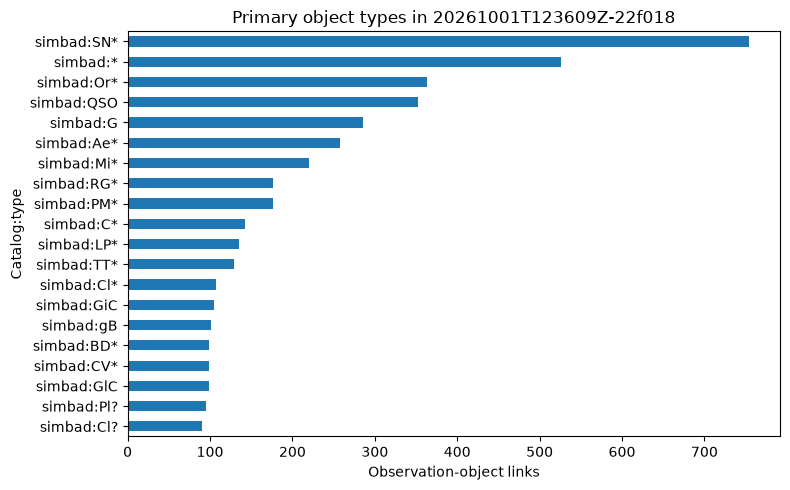

In [6]:
type_counts = pd.read_sql_query(
    """
    SELECT oo.catalog,
           COALESCE(co.primary_type_code, 'UNKNOWN') AS type_code,
           COALESCE(ot.type_label, co.primary_type_code, 'Unknown') AS type_label,
           COUNT(*) AS link_count,
           COUNT(DISTINCT oo.catalog_object_id) AS unique_objects,
           COUNT(DISTINCT oo.eso_dp_id) AS spectra
    FROM observation_objects AS oo
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    LEFT JOIN object_types AS ot
      ON ot.catalog = co.catalog
     AND ot.type_code = co.primary_type_code
    WHERE ro.run_id = ?
    GROUP BY oo.catalog, COALESCE(co.primary_type_code, 'UNKNOWN')
    ORDER BY link_count DESC, oo.catalog, type_code
    """,
    connection,
    params=(RUN_ID,),
)
display(type_counts)

plot_data = type_counts.head(20).copy()
plot_data["display_type"] = plot_data["catalog"] + ":" + plot_data["type_code"]
ax = plot_data.sort_values("link_count").plot.barh(
    x="display_type", y="link_count", legend=False, figsize=(8, 5)
)
ax.set_xlabel("Observation-object links")
ax.set_ylabel("Catalog:type")
ax.set_title(f"Primary object types in {RUN_ID}")
plt.tight_layout()

## 6. Prototype an archive query by object type

Change `TYPE_CODE` to test the archive-style lookup. Use the previous table to find valid SIMBAD codes. `CATALOG` remains set to `simbad`.

In [7]:
CATALOG = "simbad"
TYPE_CODE = "SN*"

spectra_by_type = pd.read_sql_query(
    """
    SELECT DISTINCT o.eso_dp_id, o.target_name, o.instrument_name,
           o.ra_deg, o.dec_deg,
           co.preferred_name AS matched_object,
           co.primary_type_code,
           ROUND(oo.separation_arcsec, 5) AS separation_arcsec
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN observation_objects AS oo USING (eso_dp_id)
    JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    WHERE ro.run_id = ?
      AND co.catalog = ?
      AND co.primary_type_code = ?
    ORDER BY o.eso_dp_id, oo.separation_arcsec
    """,
    connection,
    params=(RUN_ID, CATALOG, TYPE_CODE),
)
print(f"Spectra containing {CATALOG}:{TYPE_CODE}: {spectra_by_type['eso_dp_id'].nunique()}")
display(spectra_by_type)

Spectra containing simbad:SN*: 753


,eso_dp_id,target_name,instrument_name,ra_deg,dec_deg,matched_object,primary_type_code,separation_arcsec
0,ADP.2014-01-20T10:01:42.390,OGLE-2013-SN-011,EFOSC,71.795500,-64.043472,OGLE 2013-SN-11,SN*,0.00080
1,ADP.2014-01-20T10:01:42.423,LSQ12dyw,EFOSC,352.353666,-7.389083,LSQ 12dyw,SN*,0.93896
2,ADP.2014-01-20T10:01:42.430,LSQ12cda,EFOSC,207.509708,9.629805,LSQ 12cda,SN*,0.00232
3,ADP.2014-01-20T10:01:42.450,OGLE-2012-SN-006,EFOSC,53.394958,-74.394472,OGLE 2012-SN-6,SN*,0.00086
4,ADP.2014-01-20T10:01:42.463,SN2012ht,EFOSC,163.344790,16.776360,SN 2012ht,SN*,0.73801
...,...,...,...,...,...,...,...,...
749,ADP.2014-05-15T17:27:45.967,SN2010xx,XSHOOTER,311.413965,-5.586890,SN 2010gs,SN*,2.56902
750,ADP.2014-05-15T17:34:02.577,SN2010xx,XSHOOTER,311.414250,-5.587060,SN 2010gs,SN*,2.10159
751,ADP.2014-05-15T17:34:02.583,SN2010xx,XSHOOTER,311.414250,-5.587060,SN 2010gs,SN*,2.10159
752,ADP.2014-05-15T17:34:02.683,SN2010xx,XSHOOTER,311.414250,-5.587060,SN 2010gs,SN*,2.10159


## 7. A human-readable object list for each spectrum

This is close to what an archive results page could display. The relational tables remain preferable for storage because this combined string is only a presentation.

In [8]:
objects_per_spectrum = pd.read_sql_query(
    """
    SELECT o.eso_dp_id, o.target_name,
           COUNT(oo.catalog_object_id) AS object_links,
           GROUP_CONCAT(
               oo.catalog || ':' || COALESCE(co.preferred_name, co.catalog_object_id)
               || ' [' || COALESCE(co.primary_type_code, 'UNKNOWN') || ']',
               '; '
           ) AS objects_in_cone
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    LEFT JOIN observation_objects AS oo USING (eso_dp_id)
    LEFT JOIN catalog_objects AS co
      ON co.catalog = oo.catalog
     AND co.catalog_object_id = oo.catalog_object_id
    WHERE ro.run_id = ?
    GROUP BY o.eso_dp_id, o.target_name
    ORDER BY object_links DESC, o.eso_dp_id
    """,
    connection,
    params=(RUN_ID,),
)
display(objects_per_spectrum)

,eso_dp_id,target_name,object_links,objects_in_cone
0,ADP.2014-05-15T16:09:26.237,rgb_r2r5,39,simbad:CXOGlb J174804.7-244642 [X]; simbad:CXOGlb J174804.9-244642 [X]; simbad:CXOGlb J174804.5-244641 [LP*]; simbad...
1,ADP.2014-05-15T16:09:26.597,rgb_r2r5,39,simbad:CXOGlb J174804.7-244642 [X]; simbad:CXOGlb J174804.9-244642 [X]; simbad:CXOGlb J174804.5-244641 [LP*]; simbad...
2,ADP.2014-05-15T15:16:24.310,RGB.Yazan,26,simbad:[BAB2017] 330174 [MS*]; simbad:[BAB2017] 330985 [MS*]; simbad:[BAB2017] 331040 [MS*]; simbad:[BAB2017] 331087...
3,ADP.2014-05-15T15:16:24.450,RGB.Yazan,26,simbad:[BAB2017] 330174 [MS*]; simbad:[BAB2017] 330985 [MS*]; simbad:[BAB2017] 331040 [MS*]; simbad:[BAB2017] 331087...
4,ADP.2014-05-15T15:16:24.490,RGB.Yazan,26,simbad:[BAB2017] 330174 [MS*]; simbad:[BAB2017] 330985 [MS*]; simbad:[BAB2017] 331040 [MS*]; simbad:[BAB2017] 331087...
...,...,...,...,...
4995,ADP.2014-05-15T17:39:23.753,2MASS-J20035209+2320262,0,NaN
4996,ADP.2014-05-15T17:39:24.077,2MASS-J20035209+2320262,0,NaN
4997,ADP.2014-05-15T17:39:24.143,2MASS-J20035209+2320262,0,NaN
4998,ADP.2014-05-15T17:39:25.140,2MASS-J20035209+2320262,0,NaN


## 8. One best object per spectrum

The best-object table gives one simple result per ESO spectrum. SIMBAD records remain available underneath it for provenance. Name or alias matches are preferred over distance, and confidence records how decisive the choice was.

,eso_dp_id,target_name,best_object_name,broad_category,subcategory,classification_detail,confidence,match_method,separation_arcsec,candidate_group_count,supporting_catalogs,raw_catalog_types
0,ADP.2014-01-20T10:01:42.403,LSQ13sj,LSQ 13sj,Supernova,Candidate supernova,NaN,high,target_name,0.002400,1,simbad,simbad:SN?
1,ADP.2014-01-20T10:01:42.423,LSQ12dyw,LSQ 12dyw,Supernova,Unknown subtype,NaN,high,target_name,0.938958,2,simbad,simbad:SN*
2,ADP.2014-01-20T10:01:42.430,LSQ12cda,LSQ 12cda,Supernova,Unknown subtype,NaN,high,target_name,0.002324,1,simbad,simbad:SN*
3,ADP.2014-01-20T10:01:42.443,LSQ12ezn,LSQ 12ezn,Other transient,Transient Event,NaN,high,target_name,0.100000,1,simbad,simbad:ev
4,ADP.2014-01-20T10:01:42.463,SN2012ht,SN 2012ht,Supernova,Unknown subtype,NaN,high,target_name,0.738008,1,simbad,simbad:SN*
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ADP.2014-05-15T17:39:23.753,2MASS-J20035209+2320262,NaN,Unknown,NaN,NaN,none,no_catalog_match,NaN,0,NaN,NaN
4996,ADP.2014-05-15T17:39:24.077,2MASS-J20035209+2320262,NaN,Unknown,NaN,NaN,none,no_catalog_match,NaN,0,NaN,NaN
4997,ADP.2014-05-15T17:39:24.143,2MASS-J20035209+2320262,NaN,Unknown,NaN,NaN,none,no_catalog_match,NaN,0,NaN,NaN
4998,ADP.2014-05-15T17:39:25.140,2MASS-J20035209+2320262,NaN,Unknown,NaN,NaN,none,no_catalog_match,NaN,0,NaN,NaN


spectra
broad_category              subcategory                                      
Supernova                   Unknown subtype                               729
Unknown                     NaN                                           550
Galaxy                      Quasar                                        312
Star                        Orion Variable                                282
                            NaN                                           252
                            Herbig Ae/Be Star                             222
                            Mira Variable                                 220
                            High Proper Motion Star                       171
                            Carbon Star                                   140
                            Red Giant Branch star                         126
Galaxy                      NaN                                           110
Star                        T Tauri Star                                  105
                            Brown Dwarf                                    99
Galaxy                      Galaxy towards a Cluster of Galaxies           93
Star                        Red Supergiant                                 86
                            Cataclysmic Binary                             83
                            Long-Period Variable                           81
Other                       Gamma-ray Burst                                80
Star                        Be Star                                        74
                            Chemically Peculiar Star                       68
                            Low Mass X-ray Binary                          62
                            Double or Multiple Star                        59
                            Young Stellar Object                           57
                            Blue Supergiant                                57
Star cluster or association Globular Cluster                               54
Star                        Variable Star                                  52
                            OB star                                        51
                            White Dwarf                                    48
Galaxy                      Emission-line galaxy                           48
Star                        Asymptotic Giant Branch Star                   43
Nebula or ISM               Planetary Nebula                               38
Star                        High Mass X-ray Binary                         36
                            Spectroscopic Binary                           36
Galaxy                      Galaxy towards a Group of Galaxies             35
Star                        Wolf-Rayet                                     30
Galaxy                      Active Galaxy Nucleus                          28
Star cluster or association Cluster of Stars                               27
Galaxy                      BL Lac                                         24
Star                        Symbiotic Star                                 24
                            beta Cep Variable Candidate                    21
Galaxy                      Active Galaxy Nucleus Candidate                21
Other transient             Transient Event                                19
Galaxy group or cluster     Group of Galaxies                              15
Other                       Cluster of Stars Candidate                     15
Supernova                   Candidate supernova                            13
Star                        delta Sct Variable                             12
                            Red Supergiant Candidate                       12
                            Horizontal Branch Star                         12
Other                       Radio Source                                   12
Star                        OH/IR Star                                      9
              

,spectra
confidence,
high,2392
medium,1658
none,544
low,406


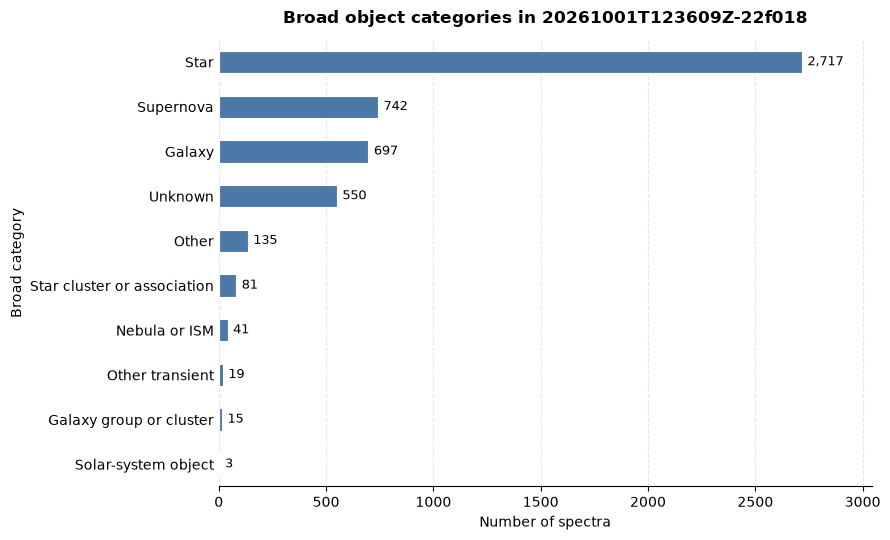

,eso_dp_id,target_name,best_object_name,confidence,match_method,candidate_group_count,all_positional_candidates
0,ADP.2014-05-15T16:09:26.237,rgb_r2r5,[BH2018] J267.019010-24.778400,low,position,39,simbad:CXOGlb J174804.7-244642 [X]; simbad:CXOGlb J174804.9-244642 [X]; simbad:CXOGlb J174804.5-244641 [LP*]; simbad...
1,ADP.2014-05-15T16:09:26.597,rgb_r2r5,[BH2018] J267.019010-24.778400,low,position,39,simbad:CXOGlb J174804.7-244642 [X]; simbad:CXOGlb J174804.9-244642 [X]; simbad:CXOGlb J174804.5-244641 [LP*]; simbad...
2,ADP.2014-05-15T15:16:24.310,RGB.Yazan,[BAB2017] 331023,low,position,26,simbad:[BAB2017] 330174 [MS*]; simbad:[BAB2017] 330985 [MS*]; simbad:[BAB2017] 331040 [MS*]; simbad:[BAB2017] 331087...
3,ADP.2014-05-15T15:16:24.450,RGB.Yazan,[BAB2017] 331023,low,position,26,simbad:[BAB2017] 330174 [MS*]; simbad:[BAB2017] 330985 [MS*]; simbad:[BAB2017] 331040 [MS*]; simbad:[BAB2017] 331087...
4,ADP.2014-05-15T15:16:24.490,RGB.Yazan,[BAB2017] 331023,low,position,26,simbad:[BAB2017] 330174 [MS*]; simbad:[BAB2017] 330985 [MS*]; simbad:[BAB2017] 331040 [MS*]; simbad:[BAB2017] 331087...
5,ADP.2014-05-15T16:09:25.983,rgb_r4r6,[BH2018] J267.017263-24.777050,low,position,14,simbad:[BH2018] J267.017375-24.776444 [*]; simbad:[BH2018] J267.017263-24.777050 [*]; simbad:[BH2018] J267.018292-24...
6,ADP.2014-05-15T16:09:25.997,rgb_r4r6,[BH2018] J267.017263-24.777050,low,position,14,simbad:[BH2018] J267.017375-24.776444 [*]; simbad:[BH2018] J267.017263-24.777050 [*]; simbad:[BH2018] J267.018292-24...
7,ADP.2014-05-15T14:17:15.117,Z-CMa,[VR2001] E,low,position,13,simbad:[DLC2022] A [mm]; simbad:[DLC2022] B [mm]; simbad:[DLC2022] C [mm]; simbad:[DLC2022] D [mm]; simbad:MWISP G22...
8,ADP.2014-05-15T14:17:15.843,Z-CMa,[VR2001] E,low,position,13,simbad:[DLC2022] A [mm]; simbad:[DLC2022] B [mm]; simbad:[DLC2022] C [mm]; simbad:[DLC2022] D [mm]; simbad:MWISP G22...
9,ADP.2014-05-15T14:17:15.850,Z-CMa,[VR2001] E,low,position,13,simbad:[DLC2022] A [mm]; simbad:[DLC2022] B [mm]; simbad:[DLC2022] C [mm]; simbad:[DLC2022] D [mm]; simbad:MWISP G22...


In [9]:
best_table_exists = connection.execute(
    "SELECT 1 FROM sqlite_master WHERE type = 'table' AND name = 'observation_best_objects'"
).fetchone()

if best_table_exists:
    best_objects = pd.read_sql_query(
        """
        SELECT bo.eso_dp_id, o.target_name, bo.best_object_name,
               bo.broad_category, bo.subcategory, bo.classification_detail,
               bo.confidence, bo.match_method, bo.separation_arcsec,
               bo.candidate_group_count, bo.supporting_catalogs,
               bo.raw_catalog_types
        FROM observation_best_objects AS bo
        JOIN observations AS o USING (eso_dp_id)
        WHERE bo.run_id = ?
        ORDER BY bo.confidence, bo.eso_dp_id
        """,
        connection,
        params=(RUN_ID,),
    )
    display(best_objects)

    category_counts = best_objects.groupby(
        ["broad_category", "subcategory"], dropna=False
    ).size().rename("spectra").sort_values(ascending=False).to_frame()
    confidence_counts = best_objects["confidence"].value_counts().rename("spectra").to_frame()
    display(category_counts)
    display(confidence_counts)

    plot_data = (
        best_objects["broad_category"]
        .fillna("Unknown")
        .value_counts()
        .sort_values()
        .rename_axis("broad_category")
        .reset_index(name="spectra")
    )
    ax = plot_data.plot.barh(
        x="broad_category",
        y="spectra",
        legend=False,
        figsize=(9, max(4, 0.55 * len(plot_data))),
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.8,
    )
    ax.bar_label(ax.containers[0], fmt="{:,.0f}", padding=4, fontsize=9)
    ax.set_xlim(0, plot_data["spectra"].max() * 1.12)
    ax.set_xlabel("Number of spectra")
    ax.set_ylabel("Broad category")
    ax.set_title(f"Broad object categories in {RUN_ID}", pad=12, weight="bold")
    ax.xaxis.grid(True, linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)
    plt.tight_layout()
    plt.show()

    review_examples = pd.read_sql_query(
        """
        SELECT bo.eso_dp_id, o.target_name, bo.best_object_name,
               bo.confidence, bo.match_method, bo.candidate_group_count,
               GROUP_CONCAT(
                   oo.catalog || ':' || COALESCE(co.preferred_name, co.catalog_object_id)
                   || ' [' || COALESCE(co.primary_type_code, 'UNKNOWN') || ']',
                   '; '
               ) AS all_positional_candidates
        FROM observation_best_objects AS bo
        JOIN observations AS o USING (eso_dp_id)
        LEFT JOIN observation_objects AS oo USING (eso_dp_id)
        LEFT JOIN catalog_objects AS co
          ON co.catalog = oo.catalog
         AND co.catalog_object_id = oo.catalog_object_id
        WHERE bo.run_id = ? AND bo.confidence IN ('low', 'none')
        GROUP BY bo.eso_dp_id, o.target_name, bo.best_object_name,
                 bo.confidence, bo.match_method, bo.candidate_group_count
        ORDER BY bo.candidate_group_count DESC, bo.eso_dp_id
        LIMIT 20
        """,
        connection,
        params=(RUN_ID,),
    )
    display(review_examples)
else:
    print("Best-object tables are not present. Run eso-object-types report to migrate and rebuild this run.")

## 9. Spectra with no catalog match

A zero-match spectrum is a valid result. It may reflect a small footprint, incomplete catalog coverage, coordinate differences, or an object missing from SIMBAD.

In [10]:
unmatched = pd.read_sql_query(
    """
    SELECT o.eso_dp_id, o.target_name, o.instrument_name,
           o.ra_deg, o.dec_deg,
           ROUND(o.search_radius_deg * 3600.0, 4) AS search_radius_arcsec
    FROM observations AS o
    JOIN run_observations AS ro USING (eso_dp_id)
    LEFT JOIN observation_objects AS oo USING (eso_dp_id)
    WHERE ro.run_id = ?
      AND oo.eso_dp_id IS NULL
    ORDER BY o.eso_dp_id
    """,
    connection,
    params=(RUN_ID,),
)
print(f"Spectra with no SIMBAD match: {len(unmatched)}")
display(unmatched)

Spectra with no SIMBAD match: 544


,eso_dp_id,target_name,instrument_name,ra_deg,dec_deg,search_radius_arcsec
0,ADP.2014-01-20T10:01:42.477,SN2012ec,SOFI,41.499500,-7.574170,1.0
1,ADP.2014-01-20T10:01:42.597,LSQ12ezu,EFOSC,355.076500,-21.155888,1.0
2,ADP.2014-01-20T10:01:42.623,LSQ12dvl,EFOSC,27.333750,1.710944,1.0
3,ADP.2014-01-20T10:01:42.663,SN2012ec,EFOSC,41.499500,-7.574170,1.0
4,ADP.2014-01-20T10:01:42.677,SN2012fr,SOFI,53.400416,-36.126111,1.0
...,...,...,...,...,...,...
539,ADP.2014-05-15T17:39:23.753,2MASS-J20035209+2320262,XSHOOTER,300.964497,23.337360,5.5
540,ADP.2014-05-15T17:39:24.077,2MASS-J20035209+2320262,XSHOOTER,300.964285,23.338050,5.5
541,ADP.2014-05-15T17:39:24.143,2MASS-J20035209+2320262,XSHOOTER,300.964497,23.337360,5.5
542,ADP.2014-05-15T17:39:25.140,2MASS-J20035209+2320262,XSHOOTER,300.964497,23.337360,5.5


## 10. Validate the stored links

All three values below should be zero. The database primary keys prevent duplicates, while the last check confirms that every link lies within the cone used for its ESO spectrum.

In [11]:
validation = pd.read_sql_query(
    """
    SELECT 'duplicate catalog object keys' AS check_name, COUNT(*) AS failures
    FROM (
        SELECT catalog, catalog_object_id
        FROM catalog_objects
        GROUP BY catalog, catalog_object_id
        HAVING COUNT(*) > 1
    )
    UNION ALL
    SELECT 'duplicate observation-object links', COUNT(*)
    FROM (
        SELECT eso_dp_id, catalog, catalog_object_id
        FROM observation_objects
        GROUP BY eso_dp_id, catalog, catalog_object_id
        HAVING COUNT(*) > 1
    )
    UNION ALL
    SELECT 'links outside search radius', COUNT(*)
    FROM observation_objects AS oo
    JOIN run_observations AS ro USING (eso_dp_id)
    JOIN observations AS o USING (eso_dp_id)
    WHERE ro.run_id = ?
      AND oo.separation_arcsec > o.search_radius_deg * 3600.0 + 1e-6
    """,
    connection,
    params=(RUN_ID,),
)
display(validation)
assert (validation["failures"] == 0).all(), "One or more database checks failed"

,check_name,failures
0,duplicate catalog object keys,0
1,duplicate observation-object links,0
2,links outside search radius,0


## 11. Read the scale estimate carefully

The estimate extrapolates the observed fraction of unique search positions to two million spectra. The SIMBAD number is a batch-count estimate, not a measured production runtime.

In [12]:
scale_metrics = {
    key: value for key, value in run_summary.items() if key.startswith("scale.")
}
display(pd.Series(scale_metrics, name="value").rename_axis("metric").to_frame())

connection.close()

,value
metric,
scale.projected_simbad_batches_for_2m,13
scale.projected_unique_positions_for_2m,637200
